Using device: cuda
GPU: Tesla T4
Memory: 15.64 GB
BERT STANCE CLASSIFICATION
Training on: 500 Pro-Climate + 500 Pro-Energy + 150 Neutral

📂 Loading and sampling training data from original CSVs...
✅ Training data loaded: 1150 samples
   Pro-Climate: 500
   Pro-Energy: 500
   Neutral: 150

📊 Data split:
  Training samples: 920
  Validation samples: 230

🔧 Initializing BERT model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...


📊 Results:
  Train Loss: 0.3544 | Train Acc: 0.8859
  Val Loss: 0.5117 | Val Acc: 0.7826
  ✅ New best model! (Val Acc: 0.7826)

Epoch 4/4


Evaluating: 100%|██████████| 15/15 [00:01<00:00,  8.28it/s]



📊 Results:
  Train Loss: 0.2424 | Train Acc: 0.9304
  Val Loss: 0.5292 | Val Acc: 0.7826

📈 FINAL EVALUATION


Evaluating: 100%|██████████| 15/15 [00:01<00:00,  8.28it/s]



Best Validation Accuracy: 0.7826

Classification Report (Validation Set):
              precision    recall  f1-score   support

     Neutral       0.74      0.47      0.57        30
 Pro-Climate       0.79      0.77      0.78       100
  Pro-Energy       0.79      0.89      0.84       100

    accuracy                           0.78       230
   macro avg       0.77      0.71      0.73       230
weighted avg       0.78      0.78      0.78       230



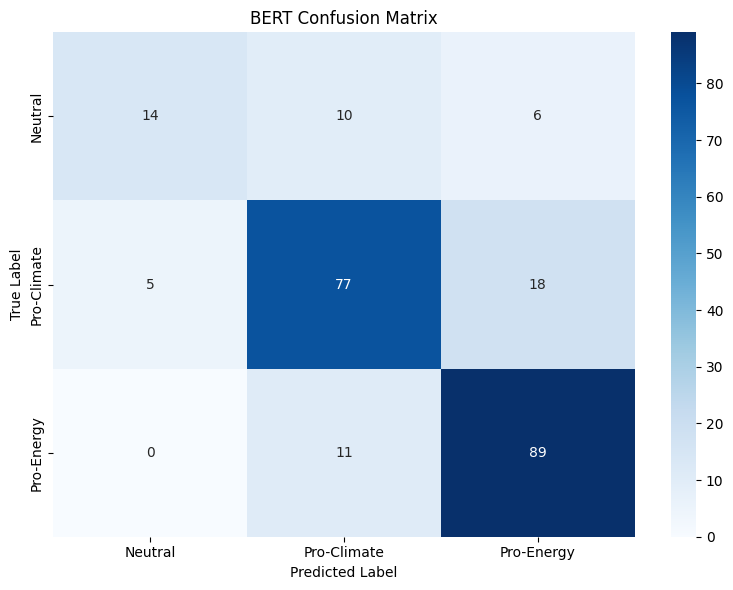

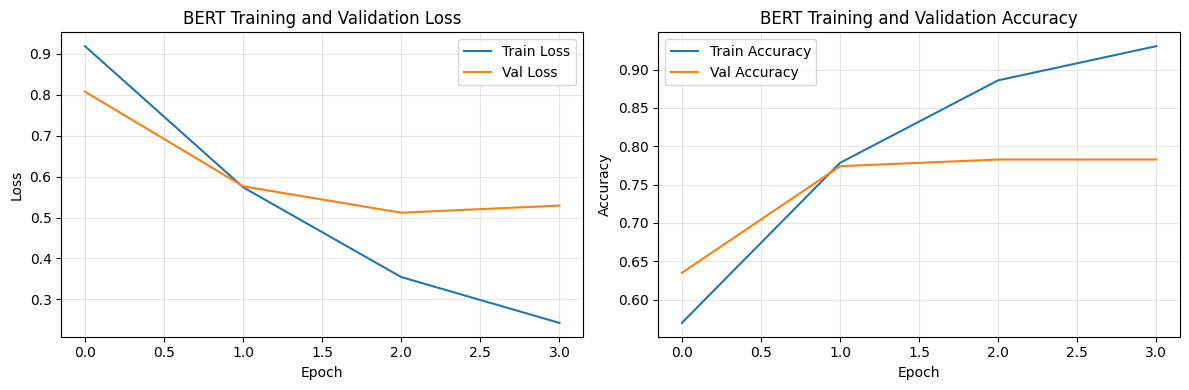


📁 CLASSIFYING FULL DATASETS

📁 Classifying meta_data.csv...


Predicting: 100%|██████████| 533/533 [02:16<00:00,  3.89it/s]



📊 Results for meta_data:
  Original rows: 17026
  Classified rows: 17026
  Saved to: bert_classified_meta_data.csv

  Label distribution:
predicted_label
Pro-Climate    10353
Pro-Energy      3579
Neutral         3094
Name: count, dtype: int64

📁 Classifying bluesky_data.csv...


Predicting: 100%|██████████| 590/590 [02:30<00:00,  3.92it/s]



📊 Results for bluesky_data:
  Original rows: 19182
  Excluded (train overlap): 331
  Classified rows: 18851
  Saved to: bert_classified_bluesky_data.csv

  Label distribution:
predicted_label
Pro-Climate    15512
Neutral         1700
Pro-Energy      1639
Name: count, dtype: int64

✅ Model saved to bert_stance_model.pt

⏱️ Total time: 0h 6m

📊 COMPARISON WITH BASELINE
Logistic Regression CV: ~79-80%
BERT Validation Accuracy: 0.7826

⚠️ BERT performs similarly to or worse than baseline


SystemExit: 0

/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
#!/usr/bin/env python3
"""
BERT-based classifier for Climate/Energy Stance Detection
Trains on 500 Pro-Climate + 500 Pro-Energy + 150 Neutral from original CSVs
"""

import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW  # Correct import
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os
import time

# -------------------
# TRAINING PATHS (same as logistic_regression.py)
# -------------------
PROCLIMATE_CSV = "proclimate.csv"
PROENERGY_CSV  = "proenergy.csv"
NEUTRAL_CSV    = "neutral.csv"

# -------------------
# FULL DATASET PATHS
# -------------------
FULL_DATASETS = {
    'meta': {
        'path': "meta_data.csv",
        'id_col': 'ad_archive_id',
        'text_col': 'ad_creative_bodies'
    },
    'bluesky': {
        'path': "bluesky_data.csv",
        'id_col': 'cid',
        'text_col': 'text'
    }
}

# -------------------
# SETTINGS
# -------------------
N_PRO_CLIMATE = 500
N_PRO_ENERGY = 500
N_NEUTRAL = 150
RANDOM_SEED = 42

# BERT Settings
MODEL_NAME = 'bert-base-uncased'
MAX_LENGTH = 128
BATCH_SIZE = 16
EPOCHS = 4
LEARNING_RATE = 2e-5

# Training files column names
TRAIN_ID_COL = "cid"
TRAIN_TEXT_COL = "text"
LABELS_ALLOWED = {"Pro-Climate", "Pro-Energy", "Neutral"}

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Normalize stance column naming."""
    df = df.copy()
    if "Stance" in df.columns and "stance" not in df.columns:
        df.rename(columns={"Stance": "stance"}, inplace=True)
    return df

def require_cols(df: pd.DataFrame, cols: set, name: str) -> None:
    missing = cols - set(df.columns)
    if missing:
        raise SystemExit(f"{name} is missing required columns: {sorted(missing)}")

def filter_to_labels(df: pd.DataFrame) -> pd.DataFrame:
    """Keep only allowed labels."""
    return df[df["stance"].isin(LABELS_ALLOWED)].copy()

def load_and_sample_training_data():
    """Load from original CSVs and sample 500/500/150"""
    print("\n📂 Loading and sampling training data from original CSVs...")

    # Load labeled training sources
    df_pc = pd.read_csv(PROCLIMATE_CSV, dtype={TRAIN_ID_COL: "string"})
    df_pe = pd.read_csv(PROENERGY_CSV, dtype={TRAIN_ID_COL: "string"})
    df_ne = pd.read_csv(NEUTRAL_CSV, dtype={TRAIN_ID_COL: "string"})

    # Normalize and filter
    df_pc = filter_to_labels(normalize_columns(df_pc))
    df_pe = filter_to_labels(normalize_columns(df_pe))
    df_ne = filter_to_labels(normalize_columns(df_ne))

    # Check if we have enough samples
    df_pc_only = df_pc[df_pc["stance"] == "Pro-Climate"]
    df_pe_only = df_pe[df_pe["stance"] == "Pro-Energy"]
    df_ne_only = df_ne[df_ne["stance"] == "Neutral"]

    if len(df_pc_only) < N_PRO_CLIMATE:
        raise SystemExit(f"Not enough Pro-Climate rows. Found {len(df_pc_only)}")
    if len(df_pe_only) < N_PRO_ENERGY:
        raise SystemExit(f"Not enough Pro-Energy rows. Found {len(df_pe_only)}")
    if len(df_ne_only) < N_NEUTRAL:
        raise SystemExit(f"Not enough Neutral rows. Found {len(df_ne_only)}")

    # Sample
    df_pc_train = df_pc_only.sample(n=N_PRO_CLIMATE, random_state=RANDOM_SEED)
    df_pe_train = df_pe_only.sample(n=N_PRO_ENERGY, random_state=RANDOM_SEED)
    df_ne_train = df_ne_only.sample(n=N_NEUTRAL, random_state=RANDOM_SEED)

    # Combine and shuffle
    train_df = pd.concat([df_pc_train, df_pe_train, df_ne_train], ignore_index=True)
    train_df = train_df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

    print(f"✅ Training data loaded: {len(train_df)} samples")
    print(f"   Pro-Climate: {len(df_pc_train)}")
    print(f"   Pro-Energy: {len(df_pe_train)}")
    print(f"   Neutral: {len(df_ne_train)}")

    return train_df

class StanceDataset(Dataset):
    """Custom Dataset for stance classification"""
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

def train_epoch(model, dataloader, optimizer, scheduler, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    predictions = []
    true_labels = []

    progress_bar = tqdm(dataloader, desc='Training')
    for batch in progress_bar:
        # Move batch to device
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Forward pass
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        total_loss += loss.item()

        # Backward pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        # Store predictions
        preds = torch.argmax(outputs.logits, dim=1)
        predictions.extend(preds.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

        # Update progress bar
        progress_bar.set_postfix({'loss': loss.item()})

    avg_loss = total_loss / len(dataloader)
    accuracy = np.mean(np.array(predictions) == np.array(true_labels))

    return avg_loss, accuracy

def evaluate(model, dataloader, device):
    """Evaluate the model"""
    model.eval()
    total_loss = 0
    predictions = []
    true_labels = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Evaluating'):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            total_loss += loss.item()

            preds = torch.argmax(outputs.logits, dim=1)
            predictions.extend(preds.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    accuracy = np.mean(np.array(predictions) == np.array(true_labels))

    return avg_loss, accuracy, predictions, true_labels

def plot_training_history(history):
    """Plot training and validation loss/accuracy"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Loss plot
    ax1.plot(history['train_loss'], label='Train Loss')
    ax1.plot(history['val_loss'], label='Val Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('BERT Training and Validation Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Accuracy plot
    ax2.plot(history['train_acc'], label='Train Accuracy')
    ax2.plot(history['val_acc'], label='Val Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title('BERT Training and Validation Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('bert_training_history.png', dpi=150)
    plt.show()

def plot_confusion_matrix(cm, class_names, title):
    """Plot confusion matrix"""
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(f'{title.lower().replace(" ", "_")}.png', dpi=150)
    plt.show()

def standardize_full_schema(df_full: pd.DataFrame, full_id_col: str, full_text_col: str) -> pd.DataFrame:
    """Rename columns to standard names"""
    df_full = df_full.copy()
    rename_map = {}
    if full_id_col != "cid":
        rename_map[full_id_col] = "cid"
    if full_text_col != "text":
        rename_map[full_text_col] = "text"
    if rename_map:
        df_full.rename(columns=rename_map, inplace=True)
    return df_full

def classify_full_dataset(model, tokenizer, dataset_config, label_map, train_ids, device):
    """Classify a full dataset using BERT"""
    print(f"\n📁 Classifying {dataset_config['path']}...")

    # Load dataset
    df_full = pd.read_csv(dataset_config['path'])

    # Standardize columns
    df_full = standardize_full_schema(df_full, dataset_config['id_col'], dataset_config['text_col'])

    # Store original row count
    original_count = len(df_full)

    # Exclude training IDs
    if 'cid' in df_full.columns:
        df_full = df_full[~df_full['cid'].isin(train_ids)].reset_index(drop=True)
        excluded_count = original_count - len(df_full)
    else:
        excluded_count = 0

    # Prepare texts
    texts = df_full['text'].fillna("").values

    # Create dataset and dataloader
    dataset = StanceDataset(texts, [0]*len(texts), tokenizer, MAX_LENGTH)
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE*2, shuffle=False)

    # Predict
    model.eval()
    all_predictions = []
    all_probabilities = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Predicting'):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            probs = torch.nn.functional.softmax(outputs.logits, dim=1)

            preds = torch.argmax(outputs.logits, dim=1)

            all_predictions.extend(preds.cpu().numpy())
            all_probabilities.extend(probs.cpu().numpy())

    # Create reverse label map
    label_map_reverse = {v: k for k, v in label_map.items()}

    # Add predictions to dataframe
    df_full['predicted_label'] = [label_map_reverse[p] for p in all_predictions]
    df_full['prob_neutral'] = [p[0] for p in all_probabilities]
    df_full['prob_pro_climate'] = [p[1] for p in all_probabilities]
    df_full['prob_pro_energy'] = [p[2] for p in all_probabilities]

    # Save
    dataset_name = os.path.basename(dataset_config['path']).replace('.csv', '')
    output_file = f"bert_classified_{dataset_name}.csv"
    df_full.to_csv(output_file, index=False)

    print(f"\n📊 Results for {dataset_name}:")
    print(f"  Original rows: {original_count}")
    if excluded_count > 0:
        print(f"  Excluded (train overlap): {excluded_count}")
    print(f"  Classified rows: {len(df_full)}")
    print(f"  Saved to: {output_file}")
    print("\n  Label distribution:")
    print(df_full['predicted_label'].value_counts())

    return df_full

def main():
    start_time = time.time()

    print("="*60)
    print("BERT STANCE CLASSIFICATION")
    print("="*60)
    print(f"Training on: {N_PRO_CLIMATE} Pro-Climate + {N_PRO_ENERGY} Pro-Energy + {N_NEUTRAL} Neutral")
    print("="*60)

    # Step 1: Load and sample training data from original CSVs
    train_df = load_and_sample_training_data()

    # Get training IDs for exclusion later
    train_ids = set(train_df[TRAIN_ID_COL].dropna().astype("string"))

    # Prepare labels
    label_map = {'Neutral': 0, 'Pro-Climate': 1, 'Pro-Energy': 2}
    train_df['label_encoded'] = train_df['stance'].map(label_map)

    # Split into train/validation (80/20)
    train_texts, val_texts, train_labels, val_labels = train_test_split(
        train_df['text'].fillna("").values,
        train_df['label_encoded'].values,
        test_size=0.2,
        random_state=RANDOM_SEED,
        stratify=train_df['label_encoded']
    )

    print(f"\n📊 Data split:")
    print(f"  Training samples: {len(train_texts)}")
    print(f"  Validation samples: {len(val_texts)}")

    # Step 2: Initialize tokenizer and model
    print("\n🔧 Initializing BERT model...")
    tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
    model = BertForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=len(label_map)
    ).to(device)

    # Print model size
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")

    # Step 3: Create datasets and dataloaders
    train_dataset = StanceDataset(train_texts, train_labels, tokenizer, MAX_LENGTH)
    val_dataset = StanceDataset(val_texts, val_labels, tokenizer, MAX_LENGTH)

    train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

    # Step 4: Setup optimizer and scheduler
    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
    total_steps = len(train_dataloader) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps
    )

    # Step 5: Training loop
    print(f"\n🚀 Starting training for {EPOCHS} epochs...")
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_accuracy = 0
    best_model_state = None

    for epoch in range(EPOCHS):
        print(f"\n{'='*50}")
        print(f"Epoch {epoch + 1}/{EPOCHS}")
        print('='*50)

        # Train
        train_loss, train_acc = train_epoch(model, train_dataloader, optimizer, scheduler, device)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)

        # Validate
        val_loss, val_acc, predictions, true_labels = evaluate(model, val_dataloader, device)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"\n📊 Results:")
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"  Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

        # Save best model
        best_model_state = model.state_dict().copy()

    # Step 6: Load best model and evaluate
    print("\n" + "="*50)
    print("📈 FINAL EVALUATION")
    print("="*50)

    model.load_state_dict(best_model_state)

    # Final validation evaluation
    _, final_val_acc, final_preds, final_labels = evaluate(model, val_dataloader, device)

    print(f"\nBest Validation Accuracy: {best_val_accuracy:.4f}")
    print("\nClassification Report (Validation Set):")
    print(classification_report(
        final_labels,
        final_preds,
        target_names=['Neutral', 'Pro-Climate', 'Pro-Energy']
    ))

    # Confusion Matrix
    cm = confusion_matrix(final_labels, final_preds)
    plot_confusion_matrix(cm,
                         ['Neutral', 'Pro-Climate', 'Pro-Energy'],
                         'BERT Confusion Matrix')

    # Plot training history
    plot_training_history(history)

    # Step 7: Classify full datasets
    print("\n" + "="*50)
    print("📁 CLASSIFYING FULL DATASETS")
    print("="*50)

    for dataset_name, config in FULL_DATASETS.items():
        classify_full_dataset(model, tokenizer, config, label_map, train_ids, device)

    # Step 8: Save model
    torch.save({
        'model_state_dict': best_model_state,
        'label_map': label_map,
        'val_accuracy': best_val_accuracy
    }, 'bert_stance_model.pt')
    print("\n✅ Model saved to bert_stance_model.pt")

    # Time report
    elapsed_time = time.time() - start_time
    hours = int(elapsed_time // 3600)
    minutes = int((elapsed_time % 3600) // 60)
    print(f"\n⏱️ Total time: {hours}h {minutes}m")


    print(f"BERT Validation Accuracy: {best_val_accuracy:.4f}")


    return 0

if __name__ == "__main__":
    raise SystemExit(main())

In [ ]:
#!/usr/bin/env python3
"""
T5-base classifier for Climate/Energy Stance Detection
Trains on 500 Pro-Climate + 500 Pro-Energy + 150 Neutral from original CSVs (old dataset)
T5-base: 220M parameters - larger than BERT but potentially more accurate
"""

import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    T5Tokenizer,
    T5ForConditionalGeneration,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os
import time
import re

# -------------------
# TRAINING PATHS
# -------------------
PROCLIMATE_CSV = "proclimate.csv"
PROENERGY_CSV  = "proenergy.csv"
NEUTRAL_CSV    = "neutral.csv"

# -------------------
# FULL DATASET PATHS
# -------------------
FULL_DATASETS = {
    'meta': {
        'path': "meta_data.csv",
        'id_col': 'ad_archive_id',
        'text_col': 'ad_creative_bodies'
    },
    'bluesky': {
        'path': "bluesky_data.csv",
        'id_col': 'cid',
        'text_col': 'text'
    }
}

# -------------------
# SETTINGS
# -------------------
N_PRO_CLIMATE = 500
N_PRO_ENERGY = 500
N_NEUTRAL = 150
RANDOM_SEED = 42

# T5 Settings
MODEL_NAME = 't5-base'  # T5-base: 220M parameters
MAX_LENGTH = 128  # Can increase to 256 if you have more VRAM
BATCH_SIZE = 8    # Smaller batch size for T5-base (it's larger)
EPOCHS = 4
LEARNING_RATE = 3e-4  # T5 typically needs higher learning rate

# Training files column names
TRAIN_ID_COL = "cid"
TRAIN_TEXT_COL = "text"
LABELS_ALLOWED = {"Pro-Climate", "Pro-Energy", "Neutral"}

# Label mapping for T5 (text-to-text format)
LABEL_TO_TEXT = {
    'Neutral': 'neutral',
    'Pro-Climate': 'pro climate',
    'Pro-Energy': 'pro energy'
}
TEXT_TO_LABEL = {v: k for k, v in LABEL_TO_TEXT.items()}

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Normalize stance column naming."""
    df = df.copy()
    if "Stance" in df.columns and "stance" not in df.columns:
        df.rename(columns={"Stance": "stance"}, inplace=True)
    return df

def require_cols(df: pd.DataFrame, cols: set, name: str) -> None:
    missing = cols - set(df.columns)
    if missing:
        raise SystemExit(f"{name} is missing required columns: {sorted(missing)}")

def filter_to_labels(df: pd.DataFrame) -> pd.DataFrame:
    """Keep only allowed labels."""
    return df[df["stance"].isin(LABELS_ALLOWED)].copy()

def load_and_sample_training_data():
    """Load from original CSVs and sample 500/500/150"""
    print("\n📂 Loading and sampling training data from original CSVs...")

    # Load labeled training sources
    df_pc = pd.read_csv(PROCLIMATE_CSV, dtype={TRAIN_ID_COL: "string"})
    df_pe = pd.read_csv(PROENERGY_CSV, dtype={TRAIN_ID_COL: "string"})
    df_ne = pd.read_csv(NEUTRAL_CSV, dtype={TRAIN_ID_COL: "string"})

    # Normalize and filter
    df_pc = filter_to_labels(normalize_columns(df_pc))
    df_pe = filter_to_labels(normalize_columns(df_pe))
    df_ne = filter_to_labels(normalize_columns(df_ne))

    # Check if we have enough samples
    df_pc_only = df_pc[df_pc["stance"] == "Pro-Climate"]
    df_pe_only = df_pe[df_pe["stance"] == "Pro-Energy"]
    df_ne_only = df_ne[df_ne["stance"] == "Neutral"]

    if len(df_pc_only) < N_PRO_CLIMATE:
        raise SystemExit(f"Not enough Pro-Climate rows. Found {len(df_pc_only)}")
    if len(df_pe_only) < N_PRO_ENERGY:
        raise SystemExit(f"Not enough Pro-Energy rows. Found {len(df_pe_only)}")
    if len(df_ne_only) < N_NEUTRAL:
        raise SystemExit(f"Not enough Neutral rows. Found {len(df_ne_only)}")

    # Sample
    df_pc_train = df_pc_only.sample(n=N_PRO_CLIMATE, random_state=RANDOM_SEED)
    df_pe_train = df_pe_only.sample(n=N_PRO_ENERGY, random_state=RANDOM_SEED)
    df_ne_train = df_ne_only.sample(n=N_NEUTRAL, random_state=RANDOM_SEED)

    # Combine and shuffle
    train_df = pd.concat([df_pc_train, df_pe_train, df_ne_train], ignore_index=True)
    train_df = train_df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

    print(f"✅ Training data loaded: {len(train_df)} samples")
    print(f"   Pro-Climate: {len(df_pc_train)}")
    print(f"   Pro-Energy: {len(df_pe_train)}")
    print(f"   Neutral: {len(df_ne_train)}")

    return train_df

class T5StanceDataset(Dataset):
    """Custom Dataset for T5 stance classification"""
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

        # T5 expects input format: "classify stance: {text}"
        self.input_prefix = "classify stance: "

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        # Prepare input with prefix
        input_text = self.input_prefix + text

        # Tokenize input
        input_encoding = self.tokenizer(
            input_text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        # Tokenize target (label)
        target_encoding = self.tokenizer(
            label,
            truncation=True,
            padding='max_length',
            max_length=8,  # Labels are short
            return_tensors='pt'
        )

        return {
            'input_ids': input_encoding['input_ids'].flatten(),
            'attention_mask': input_encoding['attention_mask'].flatten(),
            'labels': target_encoding['input_ids'].flatten(),
            'label_text': label  # Store original label for evaluation
        }

def train_epoch_t5(model, dataloader, optimizer, scheduler, device):
    """Train T5 for one epoch"""
    model.train()
    total_loss = 0
    all_predictions = []
    all_true_labels = []

    progress_bar = tqdm(dataloader, desc='Training')
    for batch in progress_bar:
        # Move batch to device
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Forward pass
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        total_loss += loss.item()

        # Backward pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        # Generate predictions for accuracy tracking (every few batches to save time)
        if len(progress_bar) % 10 == 0:
            with torch.no_grad():
                generated_ids = model.generate(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    max_length=8,
                    num_beams=1,
                    do_sample=False
                )

                # Decode predictions
                for i in range(len(generated_ids)):
                    pred_text = dataloader.dataset.tokenizer.decode(
                        generated_ids[i],
                        skip_special_tokens=True
                    ).strip().lower()
                    all_predictions.append(pred_text)
                    all_true_labels.append(batch['label_text'][i])

        # Update progress bar
        progress_bar.set_postfix({'loss': loss.item()})

    # Calculate accuracy if we have predictions
    if all_predictions:
        correct = sum([p == t for p, t in zip(all_predictions, all_true_labels)])
        accuracy = correct / len(all_predictions)
    else:
        accuracy = 0.0

    avg_loss = total_loss / len(dataloader)

    return avg_loss, accuracy

def evaluate_t5(model, dataloader, device):
    """Evaluate T5 model"""
    model.eval()
    total_loss = 0
    all_predictions = []
    all_true_labels = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Evaluating'):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # Forward pass for loss
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            total_loss += loss.item()

            # Generate predictions
            generated_ids = model.generate(
                input_ids=input_ids,
                attention_mask=attention_mask,
                max_length=8,
                num_beams=2,  # Slightly better accuracy with beam search
                do_sample=False
            )

            # Decode predictions
            for i in range(len(generated_ids)):
                pred_text = dataloader.dataset.tokenizer.decode(
                    generated_ids[i],
                    skip_special_tokens=True
                ).strip().lower()
                all_predictions.append(pred_text)
                all_true_labels.append(batch['label_text'][i])

    avg_loss = total_loss / len(dataloader)

    # Calculate accuracy
    correct = sum([p == t for p, t in zip(all_predictions, all_true_labels)])
    accuracy = correct / len(all_predictions)

    # Convert to original labels for classification report
    orig_predictions = []
    orig_true = []

    for p, t in zip(all_predictions, all_true_labels):
        # Handle cases where model might output slightly different text
        found_p = False
        for key, value in TEXT_TO_LABEL.items():
            if p == key or p in key or key in p:
                orig_predictions.append(value)
                found_p = True
                break
        if not found_p:
            orig_predictions.append('Neutral')  # Default

        orig_true.append(TEXT_TO_LABEL.get(t, 'Neutral'))

    return avg_loss, accuracy, orig_predictions, orig_true

def plot_training_history(history):
    """Plot training and validation loss/accuracy"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Loss plot
    ax1.plot(history['train_loss'], label='Train Loss')
    ax1.plot(history['val_loss'], label='Val Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('T5-base Training and Validation Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Accuracy plot
    ax2.plot(history['train_acc'], label='Train Accuracy')
    ax2.plot(history['val_acc'], label='Val Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title('T5-base Training and Validation Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('t5_base_training_history.png', dpi=150)
    plt.show()

def plot_confusion_matrix(cm, class_names, title):
    """Plot confusion matrix"""
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(f'{title.lower().replace(" ", "_")}.png', dpi=150)
    plt.show()

def standardize_full_schema(df_full: pd.DataFrame, full_id_col: str, full_text_col: str) -> pd.DataFrame:
    """Rename columns to standard names"""
    df_full = df_full.copy()
    rename_map = {}
    if full_id_col != "cid":
        rename_map[full_id_col] = "cid"
    if full_text_col != "text":
        rename_map[full_text_col] = "text"
    if rename_map:
        df_full.rename(columns=rename_map, inplace=True)
    return df_full

def classify_full_dataset_t5(model, tokenizer, dataset_config, train_ids, device):
    """Classify a full dataset using T5"""
    print(f"\n📁 Classifying {dataset_config['path']}...")

    # Load dataset
    df_full = pd.read_csv(dataset_config['path'])

    # Standardize columns
    df_full = standardize_full_schema(df_full, dataset_config['id_col'], dataset_config['text_col'])

    # Store original row count
    original_count = len(df_full)

    # Exclude training IDs
    if 'cid' in df_full.columns:
        df_full = df_full[~df_full['cid'].isin(train_ids)].reset_index(drop=True)
        excluded_count = original_count - len(df_full)
    else:
        excluded_count = 0

    # Prepare texts with prefix
    texts = ["classify stance: " + str(text) for text in df_full['text'].fillna("").values]

    # Predict in batches
    model.eval()
    all_predictions = []
    all_confidences = []

    with torch.no_grad():
        for i in tqdm(range(0, len(texts), BATCH_SIZE), desc='Predicting'):
            batch_texts = texts[i:i+BATCH_SIZE]

            # Tokenize
            inputs = tokenizer(
                batch_texts,
                truncation=True,
                padding=True,
                max_length=MAX_LENGTH,
                return_tensors='pt'
            ).to(device)

            # Generate with scores for confidence
            generated = model.generate(
                **inputs,
                max_length=8,
                num_beams=2,
                output_scores=True,
                return_dict_in_generate=True
            )

            # Decode predictions and get confidence
            for j, seq in enumerate(generated.sequences):
                pred_text = tokenizer.decode(seq, skip_special_tokens=True).strip().lower()

                # Map to original labels
                orig_label = 'Neutral'  # Default
                for key, value in TEXT_TO_LABEL.items():
                    if pred_text == key or pred_text in key or key in pred_text:
                        orig_label = value
                        break

                all_predictions.append(orig_label)

                # Approximate confidence from scores
                if generated.scores and j < len(generated.scores[0]):
                    confidence = torch.exp(generated.scores[0][j]).max().item()
                    all_confidences.append(min(confidence, 1.0))
                else:
                    all_confidences.append(0.0)

    # Add predictions to dataframe
    df_full['predicted_label'] = all_predictions
    df_full['confidence'] = all_confidences

    # Add probability columns (approximated)
    for label in ['Neutral', 'Pro-Climate', 'Pro-Energy']:
        df_full[f'prob_{label.lower().replace("-", "_")}'] = 0.0

    # Set probability for predicted class to confidence
    for idx, (label, conf) in enumerate(zip(all_predictions, all_confidences)):
        col_name = f'prob_{label.lower().replace("-", "_")}'
        if col_name in df_full.columns:
            df_full.at[idx, col_name] = conf

    # Save
    dataset_name = os.path.basename(dataset_config['path']).replace('.csv', '')
    output_file = f"t5_base_classified_{dataset_name}.csv"
    df_full.to_csv(output_file, index=False)

    print(f"\n📊 Results for {dataset_name}:")
    print(f"  Original rows: {original_count}")
    if excluded_count > 0:
        print(f"  Excluded (train overlap): {excluded_count}")
    print(f"  Classified rows: {len(df_full)}")
    print(f"  Saved to: {output_file}")
    print("\n  Label distribution:")
    print(df_full['predicted_label'].value_counts())
    print(f"\n  Average confidence: {df_full['confidence'].mean():.4f}")

    return df_full

def main():
    start_time = time.time()

    print("="*60)
    print("T5-BASE STANCE CLASSIFICATION")
    print("="*60)
    print(f"Training on: {N_PRO_CLIMATE} Pro-Climate + {N_PRO_ENERGY} Pro-Energy + {N_NEUTRAL} Neutral")
    print(f"Model: {MODEL_NAME} (220M parameters)")
    print(f"Batch size: {BATCH_SIZE} (reduce if you run out of memory)")
    print("="*60)

    # Step 1: Load and sample training data from original CSVs
    train_df = load_and_sample_training_data()

    # Get training IDs for exclusion later
    train_ids = set(train_df[TRAIN_ID_COL].dropna().astype("string"))

    # Convert labels to text format for T5
    train_df['label_text'] = train_df['stance'].map(LABEL_TO_TEXT)

    # Split into train/validation (80/20)
    train_texts, val_texts, train_labels, val_labels = train_test_split(
        train_df['text'].fillna("").values,
        train_df['label_text'].values,
        test_size=0.2,
        random_state=RANDOM_SEED,
        stratify=train_df['stance']
    )

    print(f"\n📊 Data split:")
    print(f"  Training samples: {len(train_texts)}")
    print(f"  Validation samples: {len(val_texts)}")
    print(f"\nLabel mapping for T5:")
    for original, t5_format in LABEL_TO_TEXT.items():
        print(f"  {original} → '{t5_format}'")

    # Step 2: Initialize tokenizer and model
    print("\n🔧 Initializing T5-base model...")
    tokenizer = T5Tokenizer.from_pretrained(MODEL_NAME)
    model = T5ForConditionalGeneration.from_pretrained(MODEL_NAME).to(device)

    # Print model size
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    print(f"Model size: ~{total_params * 4 / 1e9:.2f} GB in memory")

    # Step 3: Create datasets and dataloaders
    train_dataset = T5StanceDataset(train_texts, train_labels, tokenizer, MAX_LENGTH)
    val_dataset = T5StanceDataset(val_texts, val_labels, tokenizer, MAX_LENGTH)

    train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

    # Step 4: Setup optimizer and scheduler
    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
    total_steps = len(train_dataloader) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps
    )

    # Step 5: Training loop
    print(f"\n🚀 Starting training for {EPOCHS} epochs...")
    print(f"   Expected time: ~2-3 hours on T4 GPU")
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_accuracy = 0
    best_model_state = None

    for epoch in range(EPOCHS):
        print(f"\n{'='*50}")
        print(f"Epoch {epoch + 1}/{EPOCHS}")
        print('='*50)

        # Train
        train_loss, train_acc = train_epoch_t5(model, train_dataloader, optimizer, scheduler, device)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)

        # Validate
        val_loss, val_acc, val_preds, val_true = evaluate_t5(model, val_dataloader, device)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"\n📊 Results:")
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"  Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

        # Save best model
        if val_acc > best_val_accuracy:
            best_val_accuracy = val_acc
            best_model_state = model.state_dict().copy()
            print(f"  ✅ New best model! (Val Acc: {val_acc:.4f})")

    # Step 6: Load best model and evaluate
    print("\n" + "="*50)
    print("📈 FINAL EVALUATION")
    print("="*50)

    model.load_state_dict(best_model_state)

    # Final validation evaluation
    _, final_val_acc, final_preds, final_labels = evaluate_t5(model, val_dataloader, device)

    print(f"\nBest Validation Accuracy: {best_val_accuracy:.4f}")
    print("\nClassification Report (Validation Set):")
    print(classification_report(
        final_labels,
        final_preds,
        target_names=['Neutral', 'Pro-Climate', 'Pro-Energy']
    ))

    # Confusion Matrix
    cm = confusion_matrix(final_labels, final_preds)
    plot_confusion_matrix(cm,
                         ['Neutral', 'Pro-Climate', 'Pro-Energy'],
                         'T5-base Confusion Matrix')

    # Plot training history
    plot_training_history(history)

    # Step 7: Classify full datasets
    print("\n" + "="*50)
    print("📁 CLASSIFYING FULL DATASETS")
    print("="*50)

    for dataset_name, config in FULL_DATASETS.items():
        classify_full_dataset_t5(model, tokenizer, config, train_ids, device)

    # Step 8: Save model
    torch.save({
        'model_state_dict': best_model_state,
        'label_mapping': LABEL_TO_TEXT,
        'val_accuracy': best_val_accuracy
    }, 't5_base_stance_model.pt')
    print("\n✅ Model saved to t5_base_stance_model.pt")

    # Time report
    elapsed_time = time.time() - start_time
    hours = int(elapsed_time // 3600)
    minutes = int((elapsed_time % 3600) // 60)
    print(f"\n⏱️ Total time: {hours}h {minutes}m")

    print(f"T5-base Validation Accuracy: {best_val_accuracy:.4f}")

    return 0

if __name__ == "__main__":
    raise SystemExit(main())

NameError: name 'pd' is not defined

Using device: cuda
GPU: Tesla T4
Memory: 15.64 GB
T5 Small STANCE CLASSIFICATION
Training on: 500 Pro-Climate + 500 Pro-Energy + 150 Neutral
Model: t5-small (60M parameters)
Batch size: 8 (reduce if you run out of memory)

📂 Loading and sampling training data from original CSVs...
✅ Training data loaded: 1150 samples
   Pro-Climate: 500
   Pro-Energy: 500
   Neutral: 150

📊 Data split:
  Training samples: 920
  Validation samples: 230

Label mapping for T5:
  Neutral → 'neutral'
  Pro-Climate → 'pro climate'
  Pro-Energy → 'pro energy'

🔧 Initializing t5-small model...


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...


📊 Results:
  Train Loss: 0.0629 | Train Acc: 0.0000
  Val Loss: 0.0723 | Val Acc: 0.7739

Epoch 4/4


Evaluating: 100%|██████████| 29/29 [00:02<00:00, 12.54it/s]



📊 Results:
  Train Loss: 0.0484 | Train Acc: 0.0000
  Val Loss: 0.0686 | Val Acc: 0.7826
  ✅ New best model! (Val Acc: 0.7826)

📈 FINAL EVALUATION


Evaluating: 100%|██████████| 29/29 [00:02<00:00, 12.46it/s]



Best Validation Accuracy: 0.7826

Classification Report (Validation Set):
              precision    recall  f1-score   support

     Neutral       0.83      0.63      0.72        30
 Pro-Climate       0.75      0.80      0.78       100
  Pro-Energy       0.80      0.81      0.81       100

    accuracy                           0.78       230
   macro avg       0.79      0.75      0.77       230
weighted avg       0.78      0.78      0.78       230



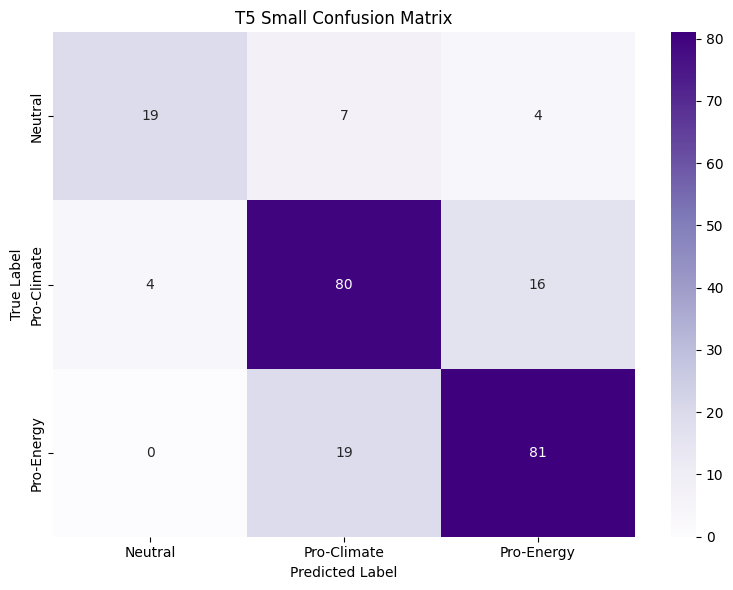

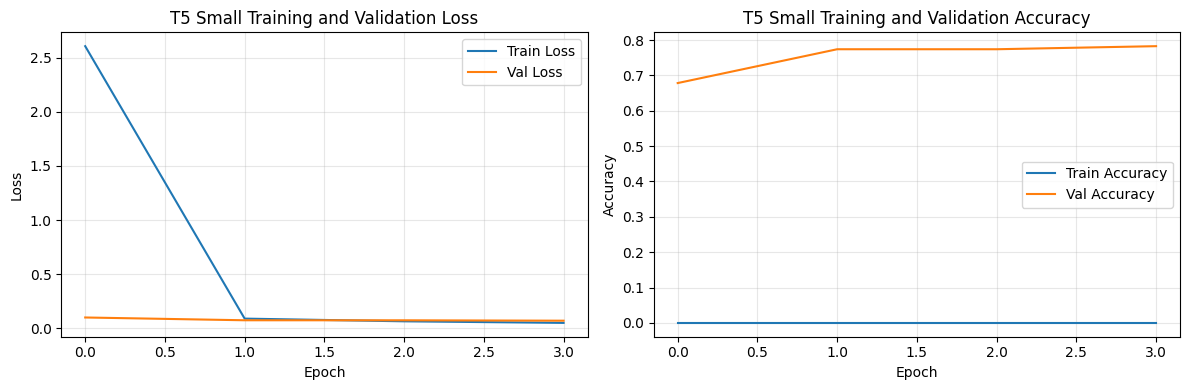


📁 CLASSIFYING FULL DATASETS

📁 Classifying meta_data.csv...


Predicting: 100%|██████████| 2129/2129 [02:06<00:00, 16.84it/s]



📊 Results for meta_data:
  Original rows: 17026
  Classified rows: 17026
  Saved to: t5_small_classified_meta_data.csv

  Label distribution:
predicted_label
Pro-Climate    10259
Pro-Energy      3411
Neutral         3356
Name: count, dtype: int64

  Average confidence: 0.9218

📁 Classifying bluesky_data.csv...


Predicting: 100%|██████████| 2357/2357 [02:09<00:00, 18.23it/s]



📊 Results for bluesky_data:
  Original rows: 19182
  Excluded (train overlap): 331
  Classified rows: 18851
  Saved to: t5_small_classified_bluesky_data.csv

  Label distribution:
predicted_label
Pro-Climate    14910
Neutral         1972
Pro-Energy      1969
Name: count, dtype: int64

  Average confidence: 0.9532

✅ Model saved to t5_small_stance_model.pt

⏱️ Total time: 0h 5m

T5 Small Validation Accuracy: 0.7826


SystemExit: 0

/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
#!/usr/bin/env python3
"""
T5-small classifier for Climate/Energy Stance Detection
Trains on 500 Pro-Climate + 500 Pro-Energy + 150 Neutral from original CSVs (old dataset)
T5-small: 220M parameters - larger than BERT but potentially more accurate
"""

import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    T5Tokenizer,
    T5ForConditionalGeneration,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os
import time
import re

# -------------------
# TRAINING PATHS
# -------------------
PROCLIMATE_CSV = "proclimate.csv"
PROENERGY_CSV  = "proenergy.csv"
NEUTRAL_CSV    = "neutral.csv"

# -------------------
# FULL DATASET PATHS
# -------------------
FULL_DATASETS = {
    'meta': {
        'path': "meta_data.csv",
        'id_col': 'ad_archive_id',
        'text_col': 'ad_creative_bodies'
    },
    'bluesky': {
        'path': "bluesky_data.csv",
        'id_col': 'cid',
        'text_col': 'text'
    }
}

# -------------------
# SETTINGS
# -------------------
N_PRO_CLIMATE = 500
N_PRO_ENERGY = 500
N_NEUTRAL = 150
RANDOM_SEED = 42

# T5 Settings
MODEL_NAME = 't5-small'
MAX_LENGTH = 128  # Can increase to 256 if you have more VRAM
BATCH_SIZE = 8    # Adjust based on model size
EPOCHS = 4
LEARNING_RATE = 3e-4  # T5 typically needs higher learning rate

# Training files column names
TRAIN_ID_COL = "cid"
TRAIN_TEXT_COL = "text"
LABELS_ALLOWED = {"Pro-Climate", "Pro-Energy", "Neutral"}

# Label mapping for T5 (text-to-text format)
LABEL_TO_TEXT = {
    'Neutral': 'neutral',
    'Pro-Climate': 'pro climate',
    'Pro-Energy': 'pro energy'
}
TEXT_TO_LABEL = {v: k for k, v in LABEL_TO_TEXT.items()}

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Normalize stance column naming."""
    df = df.copy()
    if "Stance" in df.columns and "stance" not in df.columns:
        df.rename(columns={"Stance": "stance"}, inplace=True)
    return df

def require_cols(df: pd.DataFrame, cols: set, name: str) -> None:
    missing = cols - set(df.columns)
    if missing:
        raise SystemExit(f"{name} is missing required columns: {sorted(missing)}")

def filter_to_labels(df: pd.DataFrame) -> pd.DataFrame:
    """Keep only allowed labels."""
    return df[df["stance"].isin(LABELS_ALLOWED)].copy()

def load_and_sample_training_data():
    """Load from original CSVs and sample 500/500/150"""
    print("\n📂 Loading and sampling training data from original CSVs...")

    # Load labeled training sources
    df_pc = pd.read_csv(PROCLIMATE_CSV, dtype={TRAIN_ID_COL: "string"})
    df_pe = pd.read_csv(PROENERGY_CSV, dtype={TRAIN_ID_COL: "string"})
    df_ne = pd.read_csv(NEUTRAL_CSV, dtype={TRAIN_ID_COL: "string"})

    # Normalize and filter
    df_pc = filter_to_labels(normalize_columns(df_pc))
    df_pe = filter_to_labels(normalize_columns(df_pe))
    df_ne = filter_to_labels(normalize_columns(df_ne))

    # Check if we have enough samples
    df_pc_only = df_pc[df_pc["stance"] == "Pro-Climate"]
    df_pe_only = df_pe[df_pe["stance"] == "Pro-Energy"]
    df_ne_only = df_ne[df_ne["stance"] == "Neutral"]

    if len(df_pc_only) < N_PRO_CLIMATE:
        raise SystemExit(f"Not enough Pro-Climate rows. Found {len(df_pc_only)}")
    if len(df_pe_only) < N_PRO_ENERGY:
        raise SystemExit(f"Not enough Pro-Energy rows. Found {len(df_pe_only)}")
    if len(df_ne_only) < N_NEUTRAL:
        raise SystemExit(f"Not enough Neutral rows. Found {len(df_ne_only)}")

    # Sample
    df_pc_train = df_pc_only.sample(n=N_PRO_CLIMATE, random_state=RANDOM_SEED)
    df_pe_train = df_pe_only.sample(n=N_PRO_ENERGY, random_state=RANDOM_SEED)
    df_ne_train = df_ne_only.sample(n=N_NEUTRAL, random_state=RANDOM_SEED)

    # Combine and shuffle
    train_df = pd.concat([df_pc_train, df_pe_train, df_ne_train], ignore_index=True)
    train_df = train_df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

    print(f"✅ Training data loaded: {len(train_df)} samples")
    print(f"   Pro-Climate: {len(df_pc_train)}")
    print(f"   Pro-Energy: {len(df_pe_train)}")
    print(f"   Neutral: {len(df_ne_train)}")

    return train_df

class T5StanceDataset(Dataset):
    """Custom Dataset for T5 stance classification"""
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

        # T5 expects input format: "classify stance: {text}"
        self.input_prefix = "classify stance: "

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        # Prepare input with prefix
        input_text = self.input_prefix + text

        # Tokenize input
        input_encoding = self.tokenizer(
            input_text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        # Tokenize target (label)
        target_encoding = self.tokenizer(
            label,
            truncation=True,
            padding='max_length',
            max_length=8,  # Labels are short
            return_tensors='pt'
        )

        return {
            'input_ids': input_encoding['input_ids'].flatten(),
            'attention_mask': input_encoding['attention_mask'].flatten(),
            'labels': target_encoding['input_ids'].flatten(),
            'label_text': label  # Store original label for evaluation
        }

def train_epoch_t5(model, dataloader, optimizer, scheduler, device):
    """Train T5 for one epoch"""
    model.train()
    total_loss = 0
    all_predictions = []
    all_true_labels = []

    progress_bar = tqdm(dataloader, desc='Training')
    for batch in progress_bar:
        # Move batch to device
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Forward pass
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        total_loss += loss.item()

        # Backward pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        # Generate predictions for accuracy tracking (every few batches to save time)
        if len(progress_bar) % 10 == 0:
            with torch.no_grad():
                generated_ids = model.generate(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    max_length=8,
                    num_beams=1,
                    do_sample=False
                )

                # Decode predictions
                for i in range(len(generated_ids)):
                    pred_text = dataloader.dataset.tokenizer.decode(
                        generated_ids[i],
                        skip_special_tokens=True
                    ).strip().lower()
                    all_predictions.append(pred_text)
                    all_true_labels.append(batch['label_text'][i])

        # Update progress bar
        progress_bar.set_postfix({'loss': loss.item()})

    # Calculate accuracy if we have predictions
    if all_predictions:
        correct = sum([p == t for p, t in zip(all_predictions, all_true_labels)])
        accuracy = correct / len(all_predictions)
    else:
        accuracy = 0.0

    avg_loss = total_loss / len(dataloader)

    return avg_loss, accuracy

def evaluate_t5(model, dataloader, device):
    """Evaluate T5 model"""
    model.eval()
    total_loss = 0
    all_predictions = []
    all_true_labels = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Evaluating'):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # Forward pass for loss
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            total_loss += loss.item()

            # Generate predictions
            generated_ids = model.generate(
                input_ids=input_ids,
                attention_mask=attention_mask,
                max_length=8,
                num_beams=2,  # Slightly better accuracy with beam search
                do_sample=False
            )

            # Decode predictions
            for i in range(len(generated_ids)):
                pred_text = dataloader.dataset.tokenizer.decode(
                    generated_ids[i],
                    skip_special_tokens=True
                ).strip().lower()
                all_predictions.append(pred_text)
                all_true_labels.append(batch['label_text'][i])

    avg_loss = total_loss / len(dataloader)

    # Calculate accuracy
    correct = sum([p == t for p, t in zip(all_predictions, all_true_labels)])
    accuracy = correct / len(all_predictions)

    # Convert to original labels for classification report
    orig_predictions = []
    orig_true = []

    for p, t in zip(all_predictions, all_true_labels):
        # Handle cases where model might output slightly different text
        found_p = False
        for key, value in TEXT_TO_LABEL.items():
            if p == key or p in key or key in p:
                orig_predictions.append(value)
                found_p = True
                break
        if not found_p:
            orig_predictions.append('Neutral')  # Default

        orig_true.append(TEXT_TO_LABEL.get(t, 'Neutral'))

    return avg_loss, accuracy, orig_predictions, orig_true

def plot_training_history(history):
    """Plot training and validation loss/accuracy"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Loss plot
    ax1.plot(history['train_loss'], label='Train Loss')
    ax1.plot(history['val_loss'], label='Val Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    model_display_name = MODEL_NAME.replace('-', ' ').title()
    ax1.set_title(f'{model_display_name} Training and Validation Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Accuracy plot
    ax2.plot(history['train_acc'], label='Train Accuracy')
    ax2.plot(history['val_acc'], label='Val Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title(f'{model_display_name} Training and Validation Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{MODEL_NAME.replace("-", "_")}_training_history.png', dpi=150)
    plt.show()

def plot_confusion_matrix(cm, class_names, title):
    """Plot confusion matrix"""
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    model_safe_name = MODEL_NAME.replace('-', '_').replace('/', '_')
    plt.savefig(f'{model_safe_name}_{title.lower().replace(" ", "_")}.png', dpi=150)
    plt.show()

def standardize_full_schema(df_full: pd.DataFrame, full_id_col: str, full_text_col: str) -> pd.DataFrame:
    """Rename columns to standard names"""
    df_full = df_full.copy()
    rename_map = {}
    if full_id_col != "cid":
        rename_map[full_id_col] = "cid"
    if full_text_col != "text":
        rename_map[full_text_col] = "text"
    if rename_map:
        df_full.rename(columns=rename_map, inplace=True)
    return df_full

def classify_full_dataset_t5(model, tokenizer, dataset_config, train_ids, device):
    """Classify a full dataset using T5"""
    print(f"\n📁 Classifying {dataset_config['path']}...")

    # Load dataset
    df_full = pd.read_csv(dataset_config['path'])

    # Standardize columns
    df_full = standardize_full_schema(df_full, dataset_config['id_col'], dataset_config['text_col'])

    # Store original row count
    original_count = len(df_full)

    # Exclude training IDs
    if 'cid' in df_full.columns:
        df_full = df_full[~df_full['cid'].isin(train_ids)].reset_index(drop=True)
        excluded_count = original_count - len(df_full)
    else:
        excluded_count = 0

    # Prepare texts with prefix
    texts = ["classify stance: " + str(text) for text in df_full['text'].fillna("").values]

    # Predict in batches
    model.eval()
    all_predictions = []
    all_confidences = []

    with torch.no_grad():
        for i in tqdm(range(0, len(texts), BATCH_SIZE), desc='Predicting'):
            batch_texts = texts[i:i+BATCH_SIZE]

            # Tokenize
            inputs = tokenizer(
                batch_texts,
                truncation=True,
                padding=True,
                max_length=MAX_LENGTH,
                return_tensors='pt'
            ).to(device)

            # Generate with scores for confidence
            generated = model.generate(
                **inputs,
                max_length=8,
                num_beams=2,
                output_scores=True,
                return_dict_in_generate=True
            )

            # Decode predictions and get confidence
            for j, seq in enumerate(generated.sequences):
                pred_text = tokenizer.decode(seq, skip_special_tokens=True).strip().lower()

                # Map to original labels
                orig_label = 'Neutral'  # Default
                for key, value in TEXT_TO_LABEL.items():
                    if pred_text == key or pred_text in key or key in pred_text:
                        orig_label = value
                        break

                all_predictions.append(orig_label)

                # Approximate confidence from scores
                if generated.scores and j < len(generated.scores[0]):
                    confidence = torch.exp(generated.scores[0][j]).max().item()
                    all_confidences.append(min(confidence, 1.0))
                else:
                    all_confidences.append(0.0)

    # Add predictions to dataframe
    df_full['predicted_label'] = all_predictions
    df_full['confidence'] = all_confidences

    # Add probability columns (approximated)
    for label in ['Neutral', 'Pro-Climate', 'Pro-Energy']:
        df_full[f'prob_{label.lower().replace("-", "_")}'] = 0.0

    # Set probability for predicted class to confidence
    for idx, (label, conf) in enumerate(zip(all_predictions, all_confidences)):
        col_name = f'prob_{label.lower().replace("-", "_")}'
        if col_name in df_full.columns:
            df_full.at[idx, col_name] = conf

    # Save
    dataset_name = os.path.basename(dataset_config['path']).replace('.csv', '')
    model_safe_name = MODEL_NAME.replace('-', '_').replace('/', '_')
    output_file = f"{model_safe_name}_classified_{dataset_name}.csv"
    df_full.to_csv(output_file, index=False)

    print(f"\n📊 Results for {dataset_name}:")
    print(f"  Original rows: {original_count}")
    if excluded_count > 0:
        print(f"  Excluded (train overlap): {excluded_count}")
    print(f"  Classified rows: {len(df_full)}")
    print(f"  Saved to: {output_file}")
    print("\n  Label distribution:")
    print(df_full['predicted_label'].value_counts())
    print(f"\n  Average confidence: {df_full['confidence'].mean():.4f}")

    return df_full

def main():
    start_time = time.time()

    model_display_name = MODEL_NAME.replace('-', ' ').title()
    print("="*60)
    print(f"{model_display_name} STANCE CLASSIFICATION")
    print("="*60)
    print(f"Training on: {N_PRO_CLIMATE} Pro-Climate + {N_PRO_ENERGY} Pro-Energy + {N_NEUTRAL} Neutral")

    # Get model size info
    model_size_map = {
        't5-small': '60M',
        't5-base': '220M',
        't5-large': '770M',
        't5-3b': '3B',
        't5-11b': '11B'
    }
    model_size = model_size_map.get(MODEL_NAME, 'unknown')
    print(f"Model: {MODEL_NAME} ({model_size} parameters)")
    print(f"Batch size: {BATCH_SIZE} (reduce if you run out of memory)")
    print("="*60)

    # Step 1: Load and sample training data from original CSVs
    train_df = load_and_sample_training_data()

    # Get training IDs for exclusion later
    train_ids = set(train_df[TRAIN_ID_COL].dropna().astype("string"))

    # Convert labels to text format for T5
    train_df['label_text'] = train_df['stance'].map(LABEL_TO_TEXT)

    # Split into train/validation (80/20)
    train_texts, val_texts, train_labels, val_labels = train_test_split(
        train_df['text'].fillna("").values,
        train_df['label_text'].values,
        test_size=0.2,
        random_state=RANDOM_SEED,
        stratify=train_df['stance']
    )

    print(f"\n📊 Data split:")
    print(f"  Training samples: {len(train_texts)}")
    print(f"  Validation samples: {len(val_texts)}")
    print(f"\nLabel mapping for T5:")
    for original, t5_format in LABEL_TO_TEXT.items():
        print(f"  {original} → '{t5_format}'")

    # Step 2: Initialize tokenizer and model
    print(f"\n🔧 Initializing {MODEL_NAME} model...")
    tokenizer = T5Tokenizer.from_pretrained(MODEL_NAME)
    model = T5ForConditionalGeneration.from_pretrained(MODEL_NAME).to(device)

    # Print model size
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    print(f"Model size: ~{total_params * 4 / 1e9:.2f} GB in memory")

    # Step 3: Create datasets and dataloaders
    train_dataset = T5StanceDataset(train_texts, train_labels, tokenizer, MAX_LENGTH)
    val_dataset = T5StanceDataset(val_texts, val_labels, tokenizer, MAX_LENGTH)

    train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

    # Step 4: Setup optimizer and scheduler
    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
    total_steps = len(train_dataloader) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps
    )

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_accuracy = 0
    best_model_state = None

    for epoch in range(EPOCHS):
        print(f"\n{'='*50}")
        print(f"Epoch {epoch + 1}/{EPOCHS}")
        print('='*50)

        # Train
        train_loss, train_acc = train_epoch_t5(model, train_dataloader, optimizer, scheduler, device)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)

        # Validate
        val_loss, val_acc, val_preds, val_true = evaluate_t5(model, val_dataloader, device)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"\n📊 Results:")
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"  Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

        # Save best model
        if val_acc > best_val_accuracy:
            best_val_accuracy = val_acc
            best_model_state = model.state_dict().copy()
            print(f"  ✅ New best model! (Val Acc: {val_acc:.4f})")

    # Step 6: Load best model and evaluate
    print("\n" + "="*50)
    print("📈 FINAL EVALUATION")
    print("="*50)

    model.load_state_dict(best_model_state)

    # Final validation evaluation
    _, final_val_acc, final_preds, final_labels = evaluate_t5(model, val_dataloader, device)

    print(f"\nBest Validation Accuracy: {best_val_accuracy:.4f}")
    print("\nClassification Report (Validation Set):")
    print(classification_report(
        final_labels,
        final_preds,
        target_names=['Neutral', 'Pro-Climate', 'Pro-Energy']
    ))

    # Confusion Matrix
    cm = confusion_matrix(final_labels, final_preds)
    plot_confusion_matrix(cm,
                         ['Neutral', 'Pro-Climate', 'Pro-Energy'],
                         f'{model_display_name} Confusion Matrix')

    # Plot training history
    plot_training_history(history)

    # Step 7: Classify full datasets
    print("\n" + "="*50)
    print("📁 CLASSIFYING FULL DATASETS")
    print("="*50)

    for dataset_name, config in FULL_DATASETS.items():
        classify_full_dataset_t5(model, tokenizer, config, train_ids, device)

    # Step 8: Save model
    model_safe_name = MODEL_NAME.replace('-', '_').replace('/', '_')
    torch.save({
        'model_state_dict': best_model_state,
        'label_mapping': LABEL_TO_TEXT,
        'val_accuracy': best_val_accuracy,
        'model_name': MODEL_NAME
    }, f'{model_safe_name}_stance_model.pt')
    print(f"\n✅ Model saved to {model_safe_name}_stance_model.pt")

    # Time report
    elapsed_time = time.time() - start_time
    hours = int(elapsed_time // 3600)
    minutes = int((elapsed_time % 3600) // 60)
    print(f"\n⏱️ Total time: {hours}h {minutes}m")

    print(f"\n{model_display_name} Validation Accuracy: {best_val_accuracy:.4f}")

    return 0

if __name__ == "__main__":
    raise SystemExit(main())

Using device: cuda
GPU: Tesla T4
Memory: 15.64 GB
T5 Base STANCE CLASSIFICATION
Training on: 500 Pro-Climate + 500 Pro-Energy + 150 Neutral
Model: t5-base (220M parameters)
Batch size: 8 (reduce if you run out of memory)
✅ Training data loaded: 1150 samples
   Pro-Climate: 500
   Pro-Energy: 500
   Neutral: 150

📊 Data split:
  Training samples: 920
  Validation samples: 230

Label mapping for T5:
  Neutral → 'neutral'
  Pro-Climate → 'pro climate'
  Pro-Energy → 'pro energy'

🔧 Initializing t5-base model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...


📊 Results:
  Train Loss: 0.0521 | Train Acc: 0.0000
  Val Loss: 0.0691 | Val Acc: 0.7739
  ✅ New best model! (Val Acc: 0.7739)

Epoch 4/4


Evaluating: 100%|██████████| 29/29 [00:06<00:00,  4.68it/s]



📊 Results:
  Train Loss: 0.0350 | Train Acc: 0.0000
  Val Loss: 0.0742 | Val Acc: 0.7739

📈 FINAL EVALUATION


Evaluating: 100%|██████████| 29/29 [00:05<00:00,  4.92it/s]



Best Validation Accuracy: 0.7739

Classification Report (Validation Set):
              precision    recall  f1-score   support

     Neutral       0.74      0.47      0.57        30
 Pro-Climate       0.71      0.91      0.79       100
  Pro-Energy       0.89      0.73      0.80       100

    accuracy                           0.77       230
   macro avg       0.78      0.70      0.72       230
weighted avg       0.79      0.77      0.77       230



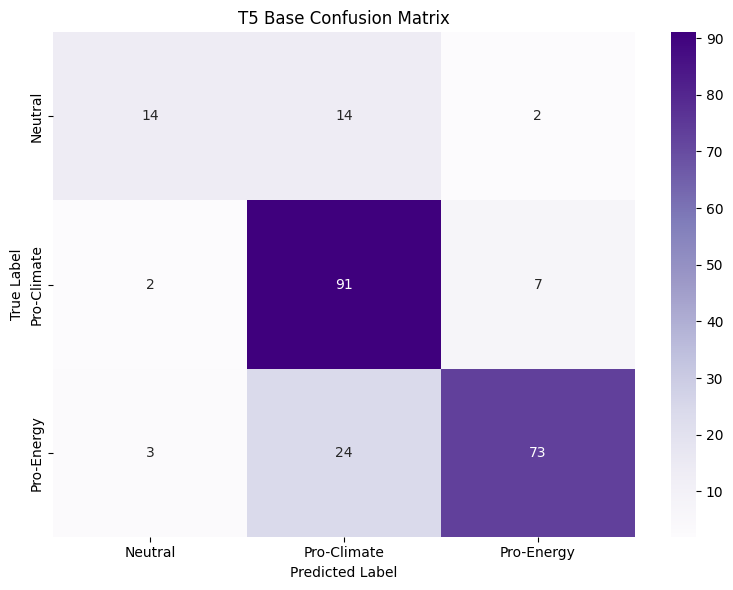

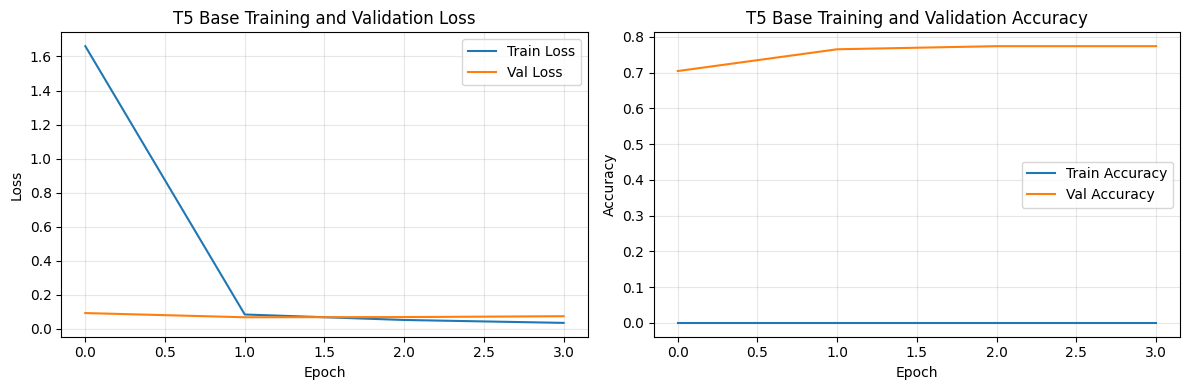


📁 CLASSIFYING FULL DATASETS

📁 Classifying meta_data.csv...


Predicting: 100%|██████████| 2129/2129 [04:36<00:00,  7.70it/s]



📊 Results for meta_data:
  Original rows: 17026
  Classified rows: 17026
  Saved to: t5_base_classified_meta_data.csv

  Label distribution:
predicted_label
Pro-Climate    11135
Pro-Energy      3624
Neutral         2267
Name: count, dtype: int64

  Average confidence: 0.9327

📁 Classifying bluesky_data.csv...


Predicting: 100%|██████████| 2357/2357 [04:11<00:00,  9.38it/s]



📊 Results for bluesky_data:
  Original rows: 19182
  Excluded (train overlap): 331
  Classified rows: 18851
  Saved to: t5_base_classified_bluesky_data.csv

  Label distribution:
predicted_label
Pro-Climate    15295
Pro-Energy      2313
Neutral         1243
Name: count, dtype: int64

  Average confidence: 0.9692

✅ Model saved to t5_base_stance_model.pt

⏱️ Total time: 0h 12m

T5 Base Validation Accuracy: 0.7739


SystemExit: 0

/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [1]:
#!/usr/bin/env python3
"""
T5-base classifier for Climate/Energy Stance Detection
Trains on 500 Pro-Climate + 500 Pro-Energy + 150 Neutral from original CSVs (NEW dataset)
T5-base: 220M parameters - larger than BERT but potentially more accurate
"""

import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    T5Tokenizer,
    T5ForConditionalGeneration,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os
import time
import re

# -------------------
# TRAINING PATHS
# -------------------
train_1150_meta_claim = "train_1150_meta_claim(in).csv"

# -------------------
# FULL DATASET PATHS
# -------------------
FULL_DATASETS = {
    'meta': {
        'path': "meta_data.csv",
        'id_col': 'ad_archive_id',
        'text_col': 'ad_creative_bodies'
    },
    'bluesky': {
        'path': "bluesky_data.csv",
        'id_col': 'cid',
        'text_col': 'text'
    }
}

# -------------------
# SETTINGS
# -------------------
N_PRO_CLIMATE = 500
N_PRO_ENERGY = 500
N_NEUTRAL = 150
RANDOM_SEED = 42

# T5 Settings
MODEL_NAME = 't5-base'  # Can be changed to 't5-small', 't5-large', etc.
MAX_LENGTH = 128  # Can increase to 256 if you have more VRAM
BATCH_SIZE = 8    # Adjust based on model size
EPOCHS = 4
LEARNING_RATE = 3e-4  # T5 typically needs higher learning rate

# Training files column names
TRAIN_ID_COL = "cid"
TRAIN_TEXT_COL = "text"
LABELS_ALLOWED = {"Pro-Climate", "Pro-Energy", "Neutral"}

# Label mapping for T5 (text-to-text format)
LABEL_TO_TEXT = {
    'Neutral': 'neutral',
    'Pro-Climate': 'pro climate',
    'Pro-Energy': 'pro energy'
}
TEXT_TO_LABEL = {v: k for k, v in LABEL_TO_TEXT.items()}

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Normalize stance column naming."""
    df = df.copy()
    if "Stance" in df.columns and "stance" not in df.columns:
        df.rename(columns={"Stance": "stance"}, inplace=True)
    return df

def require_cols(df: pd.DataFrame, cols: set, name: str) -> None:
    missing = cols - set(df.columns)
    if missing:
        raise SystemExit(f"{name} is missing required columns: {sorted(missing)}")

def filter_to_labels(df: pd.DataFrame) -> pd.DataFrame:
    """Keep only allowed labels."""
    return df[df["stance"].isin(LABELS_ALLOWED)].copy()

def load_and_sample_training_data():


    df = pd.read_csv(train_1150_meta_claim, dtype={TRAIN_ID_COL: "string"})


    df_pc = df[df["stance"] == "Pro-Climate"]
    df_pe = df[df["stance"] == "Pro-Energy"]
    df_ne = df[df["stance"] == "Neutral"]
    # Normalize and filter
    df_pc_only = filter_to_labels(normalize_columns(df_pc))
    df_pe_only = filter_to_labels(normalize_columns(df_pe))
    df_ne_only = filter_to_labels(normalize_columns(df_ne))

    if len(df_pc_only) < N_PRO_CLIMATE:
        raise SystemExit(f"Not enough Pro-Climate rows. Found {len(df_pc_only)}")
    if len(df_pe_only) < N_PRO_ENERGY:
        raise SystemExit(f"Not enough Pro-Energy rows. Found {len(df_pe_only)}")
    if len(df_ne_only) < N_NEUTRAL:
        raise SystemExit(f"Not enough Neutral rows. Found {len(df_ne_only)}")

    # Sample
    df_pc_train = df_pc_only.sample(n=N_PRO_CLIMATE, random_state=RANDOM_SEED)
    df_pe_train = df_pe_only.sample(n=N_PRO_ENERGY, random_state=RANDOM_SEED)
    df_ne_train = df_ne_only.sample(n=N_NEUTRAL, random_state=RANDOM_SEED)

    # Combine and shuffle
    train_df = pd.concat([df_pc_train, df_pe_train, df_ne_train], ignore_index=True)
    train_df = train_df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

    print(f"✅ Training data loaded: {len(train_df)} samples")
    print(f"   Pro-Climate: {len(df_pc_train)}")
    print(f"   Pro-Energy: {len(df_pe_train)}")
    print(f"   Neutral: {len(df_ne_train)}")

    return train_df

class T5StanceDataset(Dataset):
    """Custom Dataset for T5 stance classification"""
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

        # T5 expects input format: "classify stance: {text}"
        self.input_prefix = "classify stance: "

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        # Prepare input with prefix
        input_text = self.input_prefix + text

        # Tokenize input
        input_encoding = self.tokenizer(
            input_text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        # Tokenize target (label)
        target_encoding = self.tokenizer(
            label,
            truncation=True,
            padding='max_length',
            max_length=8,  # Labels are short
            return_tensors='pt'
        )

        return {
            'input_ids': input_encoding['input_ids'].flatten(),
            'attention_mask': input_encoding['attention_mask'].flatten(),
            'labels': target_encoding['input_ids'].flatten(),
            'label_text': label  # Store original label for evaluation
        }

def train_epoch_t5(model, dataloader, optimizer, scheduler, device):
    """Train T5 for one epoch"""
    model.train()
    total_loss = 0
    all_predictions = []
    all_true_labels = []

    progress_bar = tqdm(dataloader, desc='Training')
    for batch in progress_bar:
        # Move batch to device
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Forward pass
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        total_loss += loss.item()

        # Backward pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        # Generate predictions for accuracy tracking (every few batches to save time)
        if len(progress_bar) % 10 == 0:
            with torch.no_grad():
                generated_ids = model.generate(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    max_length=8,
                    num_beams=1,
                    do_sample=False
                )

                # Decode predictions
                for i in range(len(generated_ids)):
                    pred_text = dataloader.dataset.tokenizer.decode(
                        generated_ids[i],
                        skip_special_tokens=True
                    ).strip().lower()
                    all_predictions.append(pred_text)
                    all_true_labels.append(batch['label_text'][i])

        # Update progress bar
        progress_bar.set_postfix({'loss': loss.item()})

    # Calculate accuracy if we have predictions
    if all_predictions:
        correct = sum([p == t for p, t in zip(all_predictions, all_true_labels)])
        accuracy = correct / len(all_predictions)
    else:
        accuracy = 0.0

    avg_loss = total_loss / len(dataloader)

    return avg_loss, accuracy

def evaluate_t5(model, dataloader, device):
    """Evaluate T5 model"""
    model.eval()
    total_loss = 0
    all_predictions = []
    all_true_labels = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Evaluating'):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # Forward pass for loss
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            total_loss += loss.item()

            # Generate predictions
            generated_ids = model.generate(
                input_ids=input_ids,
                attention_mask=attention_mask,
                max_length=8,
                num_beams=2,  # Slightly better accuracy with beam search
                do_sample=False
            )

            # Decode predictions
            for i in range(len(generated_ids)):
                pred_text = dataloader.dataset.tokenizer.decode(
                    generated_ids[i],
                    skip_special_tokens=True
                ).strip().lower()
                all_predictions.append(pred_text)
                all_true_labels.append(batch['label_text'][i])

    avg_loss = total_loss / len(dataloader)

    # Calculate accuracy
    correct = sum([p == t for p, t in zip(all_predictions, all_true_labels)])
    accuracy = correct / len(all_predictions)

    # Convert to original labels for classification report
    orig_predictions = []
    orig_true = []

    for p, t in zip(all_predictions, all_true_labels):
        # Handle cases where model might output slightly different text
        found_p = False
        for key, value in TEXT_TO_LABEL.items():
            if p == key or p in key or key in p:
                orig_predictions.append(value)
                found_p = True
                break
        if not found_p:
            orig_predictions.append('Neutral')  # Default

        orig_true.append(TEXT_TO_LABEL.get(t, 'Neutral'))

    return avg_loss, accuracy, orig_predictions, orig_true

def plot_training_history(history):
    """Plot training and validation loss/accuracy"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Loss plot
    ax1.plot(history['train_loss'], label='Train Loss')
    ax1.plot(history['val_loss'], label='Val Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    model_display_name = MODEL_NAME.replace('-', ' ').title()
    ax1.set_title(f'{model_display_name} Training and Validation Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Accuracy plot
    ax2.plot(history['train_acc'], label='Train Accuracy')
    ax2.plot(history['val_acc'], label='Val Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title(f'{model_display_name} Training and Validation Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{MODEL_NAME.replace("-", "_")}_training_history.png', dpi=150)
    plt.show()

def plot_confusion_matrix(cm, class_names, title):
    """Plot confusion matrix"""
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    model_safe_name = MODEL_NAME.replace('-', '_').replace('/', '_')
    plt.savefig(f'{model_safe_name}_{title.lower().replace(" ", "_")}.png', dpi=150)
    plt.show()

def standardize_full_schema(df_full: pd.DataFrame, full_id_col: str, full_text_col: str) -> pd.DataFrame:
    """Rename columns to standard names"""
    df_full = df_full.copy()
    rename_map = {}
    if full_id_col != "cid":
        rename_map[full_id_col] = "cid"
    if full_text_col != "text":
        rename_map[full_text_col] = "text"
    if rename_map:
        df_full.rename(columns=rename_map, inplace=True)
    return df_full

def classify_full_dataset_t5(model, tokenizer, dataset_config, train_ids, device):
    """Classify a full dataset using T5"""
    print(f"\n📁 Classifying {dataset_config['path']}...")

    # Load dataset
    df_full = pd.read_csv(dataset_config['path'])

    # Standardize columns
    df_full = standardize_full_schema(df_full, dataset_config['id_col'], dataset_config['text_col'])

    # Store original row count
    original_count = len(df_full)

    # Exclude training IDs
    if 'cid' in df_full.columns:
        df_full = df_full[~df_full['cid'].isin(train_ids)].reset_index(drop=True)
        excluded_count = original_count - len(df_full)
    else:
        excluded_count = 0

    # Prepare texts with prefix
    texts = ["classify stance: " + str(text) for text in df_full['text'].fillna("").values]

    # Predict in batches
    model.eval()
    all_predictions = []
    all_confidences = []

    with torch.no_grad():
        for i in tqdm(range(0, len(texts), BATCH_SIZE), desc='Predicting'):
            batch_texts = texts[i:i+BATCH_SIZE]

            # Tokenize
            inputs = tokenizer(
                batch_texts,
                truncation=True,
                padding=True,
                max_length=MAX_LENGTH,
                return_tensors='pt'
            ).to(device)

            # Generate with scores for confidence
            generated = model.generate(
                **inputs,
                max_length=8,
                num_beams=2,
                output_scores=True,
                return_dict_in_generate=True
            )

            # Decode predictions and get confidence
            for j, seq in enumerate(generated.sequences):
                pred_text = tokenizer.decode(seq, skip_special_tokens=True).strip().lower()

                # Map to original labels
                orig_label = 'Neutral'  # Default
                for key, value in TEXT_TO_LABEL.items():
                    if pred_text == key or pred_text in key or key in pred_text:
                        orig_label = value
                        break

                all_predictions.append(orig_label)

                # Approximate confidence from scores
                if generated.scores and j < len(generated.scores[0]):
                    confidence = torch.exp(generated.scores[0][j]).max().item()
                    all_confidences.append(min(confidence, 1.0))
                else:
                    all_confidences.append(0.0)

    # Add predictions to dataframe
    df_full['predicted_label'] = all_predictions
    df_full['confidence'] = all_confidences

    # Add probability columns (approximated)
    for label in ['Neutral', 'Pro-Climate', 'Pro-Energy']:
        df_full[f'prob_{label.lower().replace("-", "_")}'] = 0.0

    # Set probability for predicted class to confidence
    for idx, (label, conf) in enumerate(zip(all_predictions, all_confidences)):
        col_name = f'prob_{label.lower().replace("-", "_")}'
        if col_name in df_full.columns:
            df_full.at[idx, col_name] = conf

    # Save
    dataset_name = os.path.basename(dataset_config['path']).replace('.csv', '')
    model_safe_name = MODEL_NAME.replace('-', '_').replace('/', '_')
    output_file = f"{model_safe_name}_classified_{dataset_name}.csv"
    df_full.to_csv(output_file, index=False)

    print(f"\n📊 Results for {dataset_name}:")
    print(f"  Original rows: {original_count}")
    if excluded_count > 0:
        print(f"  Excluded (train overlap): {excluded_count}")
    print(f"  Classified rows: {len(df_full)}")
    print(f"  Saved to: {output_file}")
    print("\n  Label distribution:")
    print(df_full['predicted_label'].value_counts())
    print(f"\n  Average confidence: {df_full['confidence'].mean():.4f}")

    return df_full

def main():
    start_time = time.time()

    model_display_name = MODEL_NAME.replace('-', ' ').title()
    print("="*60)
    print(f"{model_display_name} STANCE CLASSIFICATION")
    print("="*60)
    print(f"Training on: {N_PRO_CLIMATE} Pro-Climate + {N_PRO_ENERGY} Pro-Energy + {N_NEUTRAL} Neutral")

    # Get model size info
    model_size_map = {
        't5-small': '60M',
        't5-base': '220M',
        't5-large': '770M',
        't5-3b': '3B',
        't5-11b': '11B'
    }
    model_size = model_size_map.get(MODEL_NAME, 'unknown')
    print(f"Model: {MODEL_NAME} ({model_size} parameters)")
    print(f"Batch size: {BATCH_SIZE} (reduce if you run out of memory)")
    print("="*60)

    # Step 1: Load and sample training data from original CSVs
    train_df = load_and_sample_training_data()

    # Get training IDs for exclusion later
    train_ids = set(train_df[TRAIN_ID_COL].dropna().astype("string"))

    # Convert labels to text format for T5
    train_df['label_text'] = train_df['stance'].map(LABEL_TO_TEXT)

    # Split into train/validation (80/20)
    train_texts, val_texts, train_labels, val_labels = train_test_split(
        train_df['text'].fillna("").values,
        train_df['label_text'].values,
        test_size=0.2,
        random_state=RANDOM_SEED,
        stratify=train_df['stance']
    )

    print(f"\n📊 Data split:")
    print(f"  Training samples: {len(train_texts)}")
    print(f"  Validation samples: {len(val_texts)}")
    print(f"\nLabel mapping for T5:")
    for original, t5_format in LABEL_TO_TEXT.items():
        print(f"  {original} → '{t5_format}'")

    # Step 2: Initialize tokenizer and model
    print(f"\n🔧 Initializing {MODEL_NAME} model...")
    tokenizer = T5Tokenizer.from_pretrained(MODEL_NAME)
    model = T5ForConditionalGeneration.from_pretrained(MODEL_NAME).to(device)

    # Print model size
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    print(f"Model size: ~{total_params * 4 / 1e9:.2f} GB in memory")

    # Step 3: Create datasets and dataloaders
    train_dataset = T5StanceDataset(train_texts, train_labels, tokenizer, MAX_LENGTH)
    val_dataset = T5StanceDataset(val_texts, val_labels, tokenizer, MAX_LENGTH)

    train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

    # Step 4: Setup optimizer and scheduler
    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
    total_steps = len(train_dataloader) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps
    )

    # Step 5: Training loop
    print(f"\n🚀 Starting training for {EPOCHS} epochs...")
    if MODEL_NAME == 't5-base':
        print(f"   Expected time: ~2-3 hours on T4 GPU")
    elif MODEL_NAME == 't5-small':
        print(f"   Expected time: ~1-1.5 hours on T4 GPU")
    elif MODEL_NAME == 't5-large':
        print(f"   Expected time: ~4-6 hours on T4 GPU")

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_accuracy = 0
    best_model_state = None

    for epoch in range(EPOCHS):
        print(f"\n{'='*50}")
        print(f"Epoch {epoch + 1}/{EPOCHS}")
        print('='*50)

        # Train
        train_loss, train_acc = train_epoch_t5(model, train_dataloader, optimizer, scheduler, device)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)

        # Validate
        val_loss, val_acc, val_preds, val_true = evaluate_t5(model, val_dataloader, device)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"\n📊 Results:")
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"  Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

        # Save best model
        if val_acc > best_val_accuracy:
            best_val_accuracy = val_acc
            best_model_state = model.state_dict().copy()
            print(f"  ✅ New best model! (Val Acc: {val_acc:.4f})")

    # Step 6: Load best model and evaluate
    print("\n" + "="*50)
    print("📈 FINAL EVALUATION")
    print("="*50)

    model.load_state_dict(best_model_state)

    # Final validation evaluation
    _, final_val_acc, final_preds, final_labels = evaluate_t5(model, val_dataloader, device)

    print(f"\nBest Validation Accuracy: {best_val_accuracy:.4f}")
    print("\nClassification Report (Validation Set):")
    print(classification_report(
        final_labels,
        final_preds,
        target_names=['Neutral', 'Pro-Climate', 'Pro-Energy']
    ))

    # Confusion Matrix
    cm = confusion_matrix(final_labels, final_preds)
    plot_confusion_matrix(cm,
                         ['Neutral', 'Pro-Climate', 'Pro-Energy'],
                         f'{model_display_name} Confusion Matrix')

    # Plot training history
    plot_training_history(history)

    # Step 7: Classify full datasets
    print("\n" + "="*50)
    print("📁 CLASSIFYING FULL DATASETS")
    print("="*50)

    for dataset_name, config in FULL_DATASETS.items():
        classify_full_dataset_t5(model, tokenizer, config, train_ids, device)

    # Step 8: Save model
    model_safe_name = MODEL_NAME.replace('-', '_').replace('/', '_')
    torch.save({
        'model_state_dict': best_model_state,
        'label_mapping': LABEL_TO_TEXT,
        'val_accuracy': best_val_accuracy,
        'model_name': MODEL_NAME
    }, f'{model_safe_name}_stance_model.pt')
    print(f"\n✅ Model saved to {model_safe_name}_stance_model.pt")

    # Time report
    elapsed_time = time.time() - start_time
    hours = int(elapsed_time // 3600)
    minutes = int((elapsed_time % 3600) // 60)
    print(f"\n⏱️ Total time: {hours}h {minutes}m")

    print(f"\n{model_display_name} Validation Accuracy: {best_val_accuracy:.4f}")

    return 0

if __name__ == "__main__":
    raise SystemExit(main())

In [ ]:
#!/usr/bin/env python3
"""
flan_t5_xxl classifier for Climate/Energy Stance Detection
Trains on 500 Pro-Climate + 500 Pro-Energy + 150 Neutral from csv (NEW dataset)
"""

import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    T5Tokenizer,
    T5ForConditionalGeneration,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os
import time
import re

# -------------------
# TRAINING PATHS
# -------------------
train_1150_meta_claim = "train_1150_meta_claim(in).csv"

# -------------------
# FULL DATASET PATHS
# -------------------
FULL_DATASETS = {
    'meta': {
        'path': "meta_data.csv",
        'id_col': 'ad_archive_id',
        'text_col': 'ad_creative_bodies'
    },
    'bluesky': {
        'path': "bluesky_data.csv",
        'id_col': 'cid',
        'text_col': 'text'
    }
}

# -------------------
# SETTINGS
# -------------------
N_PRO_CLIMATE = 500
N_PRO_ENERGY = 500
N_NEUTRAL = 150
RANDOM_SEED = 42

# T5 Settings
MODEL_NAME = 'google/flan-t5-xxl'
MAX_LENGTH = 128  # Can increase to 256 if you have more VRAM
BATCH_SIZE = 8    # Adjust based on model size
EPOCHS = 4
LEARNING_RATE = 3e-4  # T5 typically needs higher learning rate

# Training files column names
TRAIN_ID_COL = "cid"
TRAIN_TEXT_COL = "text"
LABELS_ALLOWED = {"Pro-Climate", "Pro-Energy", "Neutral"}

# Label mapping for T5 (text-to-text format)
LABEL_TO_TEXT = {
    'Neutral': 'neutral',
    'Pro-Climate': 'pro climate',
    'Pro-Energy': 'pro energy'
}
TEXT_TO_LABEL = {v: k for k, v in LABEL_TO_TEXT.items()}

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Normalize stance column naming."""
    df = df.copy()
    if "Stance" in df.columns and "stance" not in df.columns:
        df.rename(columns={"Stance": "stance"}, inplace=True)
    return df

def require_cols(df: pd.DataFrame, cols: set, name: str) -> None:
    missing = cols - set(df.columns)
    if missing:
        raise SystemExit(f"{name} is missing required columns: {sorted(missing)}")

def filter_to_labels(df: pd.DataFrame) -> pd.DataFrame:
    """Keep only allowed labels."""
    return df[df["stance"].isin(LABELS_ALLOWED)].copy()

def load_and_sample_training_data():
    """Load from original CSVs and sample 500/500/150"""
    print("\n📂 Loading and sampling training data from original CSVs...")


    df = pd.read_csv(train_1150_meta_claim, dtype={TRAIN_ID_COL: "string"})

    df_pc_only = df[df["stance"] == "Pro-Climate"]
    df_pe_only = df[df["stance"] == "Pro-Energy"]
    df_ne_only = df[df["stance"] == "Neutral"]
    # Normalize and filter
    df_pc = filter_to_labels(normalize_columns(df_pc_only))
    df_pe = filter_to_labels(normalize_columns(df_pe_only))
    df_ne = filter_to_labels(normalize_columns(df_ne_only))

    # Check if we have enough samples


    if len(df_pc_only) < N_PRO_CLIMATE:
        raise SystemExit(f"Not enough Pro-Climate rows. Found {len(df_pc_only)}")
    if len(df_pe_only) < N_PRO_ENERGY:
        raise SystemExit(f"Not enough Pro-Energy rows. Found {len(df_pe_only)}")
    if len(df_ne_only) < N_NEUTRAL:
        raise SystemExit(f"Not enough Neutral rows. Found {len(df_ne_only)}")

    # Sample
    df_pc_train = df_pc_only.sample(n=N_PRO_CLIMATE, random_state=RANDOM_SEED)
    df_pe_train = df_pe_only.sample(n=N_PRO_ENERGY, random_state=RANDOM_SEED)
    df_ne_train = df_ne_only.sample(n=N_NEUTRAL, random_state=RANDOM_SEED)

    # Combine and shuffle
    train_df = pd.concat([df_pc_train, df_pe_train, df_ne_train], ignore_index=True)
    train_df = train_df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

    print(f"✅ Training data loaded: {len(train_df)} samples")
    print(f"   Pro-Climate: {len(df_pc_train)}")
    print(f"   Pro-Energy: {len(df_pe_train)}")
    print(f"   Neutral: {len(df_ne_train)}")

    return train_df

class T5StanceDataset(Dataset):
    """Custom Dataset for T5 stance classification"""
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

        # T5 expects input format: "classify stance: {text}"
        self.input_prefix = "classify stance: "

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        # Prepare input with prefix
        input_text = self.input_prefix + text

        # Tokenize input
        input_encoding = self.tokenizer(
            input_text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        # Tokenize target (label)
        target_encoding = self.tokenizer(
            label,
            truncation=True,
            padding='max_length',
            max_length=8,  # Labels are short
            return_tensors='pt'
        )

        return {
            'input_ids': input_encoding['input_ids'].flatten(),
            'attention_mask': input_encoding['attention_mask'].flatten(),
            'labels': target_encoding['input_ids'].flatten(),
            'label_text': label  # Store original label for evaluation
        }

def train_epoch_t5(model, dataloader, optimizer, scheduler, device):
    """Train T5 for one epoch"""
    model.train()
    total_loss = 0
    all_predictions = []
    all_true_labels = []

    progress_bar = tqdm(dataloader, desc='Training')
    for batch in progress_bar:
        # Move batch to device
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Forward pass
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        total_loss += loss.item()

        # Backward pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        # Generate predictions for accuracy tracking (every few batches to save time)
        if len(progress_bar) % 10 == 0:
            with torch.no_grad():
                generated_ids = model.generate(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    max_length=8,
                    num_beams=1,
                    do_sample=False
                )

                # Decode predictions
                for i in range(len(generated_ids)):
                    pred_text = dataloader.dataset.tokenizer.decode(
                        generated_ids[i],
                        skip_special_tokens=True
                    ).strip().lower()
                    all_predictions.append(pred_text)
                    all_true_labels.append(batch['label_text'][i])

        # Update progress bar
        progress_bar.set_postfix({'loss': loss.item()})

    # Calculate accuracy if we have predictions
    if all_predictions:
        correct = sum([p == t for p, t in zip(all_predictions, all_true_labels)])
        accuracy = correct / len(all_predictions)
    else:
        accuracy = 0.0

    avg_loss = total_loss / len(dataloader)

    return avg_loss, accuracy

def evaluate_t5(model, dataloader, device):
    """Evaluate T5 model"""
    model.eval()
    total_loss = 0
    all_predictions = []
    all_true_labels = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Evaluating'):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # Forward pass for loss
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            total_loss += loss.item()

            # Generate predictions
            generated_ids = model.generate(
                input_ids=input_ids,
                attention_mask=attention_mask,
                max_length=8,
                num_beams=2,  # Slightly better accuracy with beam search
                do_sample=False
            )

            # Decode predictions
            for i in range(len(generated_ids)):
                pred_text = dataloader.dataset.tokenizer.decode(
                    generated_ids[i],
                    skip_special_tokens=True
                ).strip().lower()
                all_predictions.append(pred_text)
                all_true_labels.append(batch['label_text'][i])

    avg_loss = total_loss / len(dataloader)

    # Calculate accuracy
    correct = sum([p == t for p, t in zip(all_predictions, all_true_labels)])
    accuracy = correct / len(all_predictions)

    # Convert to original labels for classification report
    orig_predictions = []
    orig_true = []

    for p, t in zip(all_predictions, all_true_labels):
        # Handle cases where model might output slightly different text
        found_p = False
        for key, value in TEXT_TO_LABEL.items():
            if p == key or p in key or key in p:
                orig_predictions.append(value)
                found_p = True
                break
        if not found_p:
            orig_predictions.append('Neutral')  # Default

        orig_true.append(TEXT_TO_LABEL.get(t, 'Neutral'))

    return avg_loss, accuracy, orig_predictions, orig_true

def plot_training_history(history):
    """Plot training and validation loss/accuracy"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Loss plot
    ax1.plot(history['train_loss'], label='Train Loss')
    ax1.plot(history['val_loss'], label='Val Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    model_display_name = MODEL_NAME.replace('-', ' ').title()
    ax1.set_title(f'{model_display_name} Training and Validation Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Accuracy plot
    ax2.plot(history['train_acc'], label='Train Accuracy')
    ax2.plot(history['val_acc'], label='Val Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title(f'{model_display_name} Training and Validation Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{MODEL_NAME.replace("-", "_")}_training_history.png', dpi=150)
    plt.show()

def plot_confusion_matrix(cm, class_names, title):
    """Plot confusion matrix"""
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    model_safe_name = MODEL_NAME.replace('-', '_').replace('/', '_')
    plt.savefig(f'{model_safe_name}_{title.lower().replace(" ", "_")}.png', dpi=150)
    plt.show()

def standardize_full_schema(df_full: pd.DataFrame, full_id_col: str, full_text_col: str) -> pd.DataFrame:
    """Rename columns to standard names"""
    df_full = df_full.copy()
    rename_map = {}
    if full_id_col != "cid":
        rename_map[full_id_col] = "cid"
    if full_text_col != "text":
        rename_map[full_text_col] = "text"
    if rename_map:
        df_full.rename(columns=rename_map, inplace=True)
    return df_full

def classify_full_dataset_t5(model, tokenizer, dataset_config, train_ids, device):
    """Classify a full dataset using T5"""
    print(f"\n📁 Classifying {dataset_config['path']}...")

    # Load dataset
    df_full = pd.read_csv(dataset_config['path'])

    # Standardize columns
    df_full = standardize_full_schema(df_full, dataset_config['id_col'], dataset_config['text_col'])

    # Store original row count
    original_count = len(df_full)

    # Exclude training IDs
    if 'cid' in df_full.columns:
        df_full = df_full[~df_full['cid'].isin(train_ids)].reset_index(drop=True)
        excluded_count = original_count - len(df_full)
    else:
        excluded_count = 0

    # Prepare texts with prefix
    texts = ["classify stance: " + str(text) for text in df_full['text'].fillna("").values]

    # Predict in batches
    model.eval()
    all_predictions = []
    all_confidences = []

    with torch.no_grad():
        for i in tqdm(range(0, len(texts), BATCH_SIZE), desc='Predicting'):
            batch_texts = texts[i:i+BATCH_SIZE]

            # Tokenize
            inputs = tokenizer(
                batch_texts,
                truncation=True,
                padding=True,
                max_length=MAX_LENGTH,
                return_tensors='pt'
            ).to(device)

            # Generate with scores for confidence
            generated = model.generate(
                **inputs,
                max_length=8,
                num_beams=2,
                output_scores=True,
                return_dict_in_generate=True
            )

            # Decode predictions and get confidence
            for j, seq in enumerate(generated.sequences):
                pred_text = tokenizer.decode(seq, skip_special_tokens=True).strip().lower()

                # Map to original labels
                orig_label = 'Neutral'  # Default
                for key, value in TEXT_TO_LABEL.items():
                    if pred_text == key or pred_text in key or key in pred_text:
                        orig_label = value
                        break

                all_predictions.append(orig_label)

                # Approximate confidence from scores
                if generated.scores and j < len(generated.scores[0]):
                    confidence = torch.exp(generated.scores[0][j]).max().item()
                    all_confidences.append(min(confidence, 1.0))
                else:
                    all_confidences.append(0.0)

    # Add predictions to dataframe
    df_full['predicted_label'] = all_predictions
    df_full['confidence'] = all_confidences

    # Add probability columns (approximated)
    for label in ['Neutral', 'Pro-Climate', 'Pro-Energy']:
        df_full[f'prob_{label.lower().replace("-", "_")}'] = 0.0

    # Set probability for predicted class to confidence
    for idx, (label, conf) in enumerate(zip(all_predictions, all_confidences)):
        col_name = f'prob_{label.lower().replace("-", "_")}'
        if col_name in df_full.columns:
            df_full.at[idx, col_name] = conf

    # Save
    dataset_name = os.path.basename(dataset_config['path']).replace('.csv', '')
    model_safe_name = MODEL_NAME.replace('-', '_').replace('/', '_')
    output_file = f"{model_safe_name}_classified_{dataset_name}.csv"
    df_full.to_csv(output_file, index=False)

    print(f"\n📊 Results for {dataset_name}:")
    print(f"  Original rows: {original_count}")
    if excluded_count > 0:
        print(f"  Excluded (train overlap): {excluded_count}")
    print(f"  Classified rows: {len(df_full)}")
    print(f"  Saved to: {output_file}")
    print("\n  Label distribution:")
    print(df_full['predicted_label'].value_counts())
    print(f"\n  Average confidence: {df_full['confidence'].mean():.4f}")

    return df_full

def main():
    start_time = time.time()

    model_display_name = MODEL_NAME.replace('-', ' ').title()
    print("="*60)
    print(f"{model_display_name} STANCE CLASSIFICATION")
    print("="*60)
    print(f"Training on: {N_PRO_CLIMATE} Pro-Climate + {N_PRO_ENERGY} Pro-Energy + {N_NEUTRAL} Neutral")

    # Get model size info
    model_size_map = {
        't5-small': '60M',
        't5-base': '220M',
        't5-large': '770M',
        't5-3b': '3B',
        't5-11b': '11B'
    }
    model_size = model_size_map.get(MODEL_NAME, 'unknown')
    print(f"Model: {MODEL_NAME} ({model_size} parameters)")
    print(f"Batch size: {BATCH_SIZE} (reduce if you run out of memory)")
    print("="*60)

    # Step 1: Load and sample training data from original CSVs
    train_df = load_and_sample_training_data()

    # Get training IDs for exclusion later
    train_ids = set(train_df[TRAIN_ID_COL].dropna().astype("string"))

    # Convert labels to text format for T5
    train_df['label_text'] = train_df['stance'].map(LABEL_TO_TEXT)

    # Split into train/validation (80/20)
    train_texts, val_texts, train_labels, val_labels = train_test_split(
        train_df['text'].fillna("").values,
        train_df['label_text'].values,
        test_size=0.2,
        random_state=RANDOM_SEED,
        stratify=train_df['stance']
    )

    print(f"\n📊 Data split:")
    print(f"  Training samples: {len(train_texts)}")
    print(f"  Validation samples: {len(val_texts)}")
    print(f"\nLabel mapping for T5:")
    for original, t5_format in LABEL_TO_TEXT.items():
        print(f"  {original} → '{t5_format}'")

    # Step 2: Initialize tokenizer and model
    print(f"\n🔧 Initializing {MODEL_NAME} model...")
    tokenizer = T5Tokenizer.from_pretrained(MODEL_NAME)
    model = T5ForConditionalGeneration.from_pretrained(MODEL_NAME).to(device)

    # Print model size
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    print(f"Model size: ~{total_params * 4 / 1e9:.2f} GB in memory")

    # Step 3: Create datasets and dataloaders
    train_dataset = T5StanceDataset(train_texts, train_labels, tokenizer, MAX_LENGTH)
    val_dataset = T5StanceDataset(val_texts, val_labels, tokenizer, MAX_LENGTH)

    train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

    # Step 4: Setup optimizer and scheduler
    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
    total_steps = len(train_dataloader) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps
    )

    # Step 5: Training loop
    print(f"\n🚀 Starting training for {EPOCHS} epochs...")
    if MODEL_NAME == 't5-base':
        print(f"   Expected time: ~2-3 hours on T4 GPU")
    elif MODEL_NAME == 't5-small':
        print(f"   Expected time: ~1-1.5 hours on T4 GPU")
    elif MODEL_NAME == 't5-large':
        print(f"   Expected time: ~4-6 hours on T4 GPU")

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_accuracy = 0
    best_model_state = None

    for epoch in range(EPOCHS):
        print(f"\n{'='*50}")
        print(f"Epoch {epoch + 1}/{EPOCHS}")
        print('='*50)

        # Train
        train_loss, train_acc = train_epoch_t5(model, train_dataloader, optimizer, scheduler, device)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)

        # Validate
        val_loss, val_acc, val_preds, val_true = evaluate_t5(model, val_dataloader, device)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"\n📊 Results:")
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"  Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

        # Save best model
        if val_acc > best_val_accuracy:
            best_val_accuracy = val_acc
            best_model_state = model.state_dict().copy()
            print(f"  ✅ New best model! (Val Acc: {val_acc:.4f})")

    # Step 6: Load best model and evaluate
    print("\n" + "="*50)
    print("📈 FINAL EVALUATION")
    print("="*50)

    model.load_state_dict(best_model_state)

    # Final validation evaluation
    _, final_val_acc, final_preds, final_labels = evaluate_t5(model, val_dataloader, device)

    print(f"\nBest Validation Accuracy: {best_val_accuracy:.4f}")
    print("\nClassification Report (Validation Set):")
    print(classification_report(
        final_labels,
        final_preds,
        target_names=['Neutral', 'Pro-Climate', 'Pro-Energy']
    ))

    # Confusion Matrix
    cm = confusion_matrix(final_labels, final_preds)
    plot_confusion_matrix(cm,
                         ['Neutral', 'Pro-Climate', 'Pro-Energy'],
                         f'{model_display_name} Confusion Matrix')

    # Plot training history
    plot_training_history(history)

    # Step 7: Classify full datasets
    print("\n" + "="*50)
    print("📁 CLASSIFYING FULL DATASETS")
    print("="*50)

    for dataset_name, config in FULL_DATASETS.items():
        classify_full_dataset_t5(model, tokenizer, config, train_ids, device)

    # Step 8: Save model
    model_safe_name = MODEL_NAME.replace('-', '_').replace('/', '_')
    torch.save({
        'model_state_dict': best_model_state,
        'label_mapping': LABEL_TO_TEXT,
        'val_accuracy': best_val_accuracy,
        'model_name': MODEL_NAME
    }, f'{model_safe_name}_stance_model.pt')
    print(f"\n✅ Model saved to {model_safe_name}_stance_model.pt")

    # Time report
    elapsed_time = time.time() - start_time
    hours = int(elapsed_time // 3600)
    minutes = int((elapsed_time % 3600) // 60)
    print(f"\n⏱️ Total time: {hours}h {minutes}m")

    print(f"\n{model_display_name} Validation Accuracy: {best_val_accuracy:.4f}")

    return 0

if __name__ == "__main__":
    raise SystemExit(main())

Using device: cuda
GPU: Tesla T4
Memory: 15.64 GB
Google/Flan T5 Xxl STANCE CLASSIFICATION
Training on: 500 Pro-Climate + 500 Pro-Energy + 150 Neutral
Model: google/flan-t5-xxl (unknown parameters)
Batch size: 8 (reduce if you run out of memory)

📂 Loading and sampling training data from original CSVs...
✅ Training data loaded: 1150 samples
   Pro-Climate: 500
   Pro-Energy: 500
   Neutral: 150

📊 Data split:
  Training samples: 920
  Validation samples: 230

Label mapping for T5:
  Neutral → 'neutral'
  Pro-Climate → 'pro climate'
  Pro-Energy → 'pro energy'

🔧 Initializing google/flan-t5-xxl model...


KeyboardInterrupt: 